<style>
/* --- print/PDF tuning ---------------------------------------------------
   The statsmodels-style summary() output is 88 characters wide. At the
   template's default font size those lines wrap awkwardly in the PDF, so we
   shrink monospaced output (stdout text and code) just enough to fit one line
   on the page. Screen rendering of the notebook is unaffected when viewed in
   Jupyter, since this style only matters for the static HTML/PDF export. */
.jp-OutputArea-output pre,
.jp-RenderedText pre,
div.output_text pre,
pre {
    font-size: 9.5px !important;
    line-height: 1.25 !important;
    white-space: pre !important;
}
.jp-InputArea-editor,
.highlight pre,
.jp-CodeMirrorEditor {
    font-size: 10.5px !important;
}
@page {
    margin: 1.3cm 1.3cm 1.6cm 1.3cm;   /* extra bottom margin for the page number */
    @bottom-right {
        content: counter(page);
        font-family: sans-serif;
        font-size: 9px;
        color: #666;
    }
}
</style>

# censtrunc
## Цензурированная и усечённая нормальная регрессия с произвольными порогами

**Автор:** Рамис Пайгин  
**Пакет:** `censtrunc` v0.1.0  
**Репозиторий:** [github.com/Ramis-Paygin/censored-truncated-regression](https://github.com/Ramis-Paygin/censored-truncated-regression)  

---

### Аннотация

`censtrunc` — Python-пакет для оценивания методом максимального правдоподобия двух семейств моделей с ограниченной зависимой переменной: (i) **цензурированной и усечённой нормальной регрессии** с произвольными левым и правым порогами, обобщающей классическую модель Тобита [1], и (ii) **модели Хекмана** [3], причём поддерживаются как двухшаговый метод оценивания, так и совместное оценивание методом максимального правдоподобия. Пакет предоставляет программный интерфейс в стиле scikit-learn, итоговую таблицу результатов в стиле statsmodels, оценивание предельных эффектов через `get_margeff`, тест отношения правдоподобия с гипотезой в виде строки и поддержку формул в стиле patsy. В цензурированном случае используется глобально вогнутая параметризация Олсена [2].

Отчёт построен по двум семействам моделей. Каждая часть содержит три раздела: **теория**, **примеры применения** библиотеки на симулированных и реальных данных, **эмпирическая проверка корректности** — аналитические предельные случаи и кросс-валидация на тех же данных с независимыми реализациями. Полные библиографические ссылки приведены в конце отчёта.

## 1. Введение

Обычная линейная регрессия предполагает, что зависимая переменная наблюдается на всей вещественной оси. На практике она часто ограничена:

- **Цензурирование**: значения вне интервала $(L, R)$ заменяются ближайшей границей. Типичные примеры: оценка удовлетворённости по шкале 0–10 или заработная плата, ограниченная установленным в организации максимальным уровнем оплаты труда.
- **Усечение**: значения вне $[L, R]$ полностью отсутствуют в выборке. Так устроены опросные данные, регистрирующие только респондентов с доходом выше определённого уровня, или административные данные о сделках выше порога обязательной отчётности.
- **Данные, подверженные селекции выборки**: переменная наблюдается лишь тогда, когда срабатывает отдельное *уравнение отбора*. Зарплата фиксируется только у занятых; объём потребления — только у согласившихся участвовать в опросе.

Метод наименьших квадратов даёт смещённые оценки во всех трёх случаях. Классические решения: **модель Тобита** [1] для односторонней цензуры в нуле, **усечённая нормальная регрессия** для одностороннего  усечения и **модель Хекмана** [3] — для третьего случая.

`censtrunc` объединяет все три модели в одной Python-библиотеке. Все они используют согласованный программный интерфейс для оценивания, построения прогнозов и интерпретации результатов (`predict`, `get_margeff`, `lr_test`, `from_formula`). Разделы 3 и 4 разбирают эти три модели по двум классам: цензурированную и усечённую регрессию — в части А, модель Хекмана — в части Б.

## 2. Что уже реализовано в Python

В R соответствующие модели реализованы давно и удобно: пакет `survival::survreg` (на нём построен `AER::tobit`) покрывает цензурированный случай, `truncreg::truncreg` — усечённый, а `sampleSelection::selection` [7] — обе версии оценки модели Хекмана. В Python соответствующие реализации разрознены и покрывают эти модели лишь частично.

| Пакет | Цензурирование / Tobit | Усечение | Хекит | Замечания |
|---|---|---|---|---|
| **statsmodels** | публичного Tobit-класса нет | в публичном программном интерфейсе отсутствует | не реализован | Естественный первый кандидат — именно эти модели и составляют пробел. |
| **scikit-learn** | — | — | — | Моделей с ограниченной зависимой переменной нет. |
| **linearmodels** | — | — | — | Специализация — панельные данные, инструментальные переменные, обобщённый метод моментов. |
| **lifelines** | левая цензура в модели Вейбулла и логнормальной модели ускоренного времени отказа (AFT — accelerated failure time) | — | — | Survival-фреймворк: коэффициенты в терминах hazard ratio; ненулевой $L$ выражать неудобно. |
| **scikit-survival** | правая цензура, модели ускоренного времени отказа | — | — | Тот же survival-подход. |
| **py4etrics** | `Tobit` с произвольными $L, R$ | `Truncreg` с произвольными $L, R$ | двухшаговый `Heckit` (значение `method='mle'` по умолчанию игнорируется) | Учебный пакет; предельных эффектов, теста отношения правдоподобия и формул нет. |
| **stnwanekezie/TobitRegression** | один класс `Tobit` поверх `statsmodels.OLS` | — | — | Скрипт около 425 строк; доступна только сводка `summary()`. |
| **PyMC / bambi** | байесовский вариант через `Censored` | байесовский вариант через `Truncated` | можно собрать вручную | Байесовский подход с использованием методов Монте-Карло на марковских цепях (MCMC). |
| **marginaleffects** | — | — | — | Инструмент для предельных эффектов и контрастов; модели не оценивает. |

### Что нового добавляет `censtrunc`

- **Двустороннее цензурирование и усечение** с произвольными границами $L$ и $R$ во всех трёх оценщиках (односторонний случай получается как частный).
- **Совместная оценка модели Хекмана методом максимального правдоподобия** (как у `sampleSelection::selection`), а не только двухшаговый алгоритм; для двухшагового реализован парный бутстрап стандартных ошибок.
- **Предельные эффекты** через единый `get_margeff` в стиле statsmodels для всех трёх моделей. Цензурированные модели дополнительно отдают три эффекта на граничные и внутренние вероятности — $P(Y=L)$, $P(L<Y<R)$, $P(Y=R)$; модели Хекмана — четыре (`latent`, `conditional`, `unconditional`, `prob-selected`).
- **Тест отношения правдоподобия** в двух вариантах: между парой оценённых моделей либо `model.lr_test(hypotheses)` со строкой гипотез (`'(x1 = 0), (x2 = x3)'`, `'2*x1 + x4 = 1'`).
- **Формулы в стиле patsy** поддерживаются во всех трёх классах.
- Единый `predict()` возвращает любое подмножество из шести величин через однобуквенную строку `kind`: для цензурированной модели это `'hctlmr'`, для модели Хекмана — `'snpohu'`.
- **Перекрёстная проверка результатов (cross-validation)** с внешними реализациями в наборе тестов — см. §3.3 и §4.3.

---

# Часть А. Цензурированная и усечённая нормальная регрессия

## 3.1 Теория

### Латентная регрессия

Обе модели используют одну и ту же спецификацию латентной линейной регрессии с нормально распределёнными ошибками:

$$Y^* = X'\beta + e, \qquad e \mid X \sim \mathcal{N}(0, \sigma^2).$$

Различие между ними заключается в правиле, связывающем латентную переменную $Y^*$ с наблюдаемыми данными.

### Цензурированная модель

Значения за пределами интервала $(L, R)$ заменяются ближайшей границей:

$$Y = \min\bigl(R,\; \max(L,\; Y^*)\bigr).$$

Обозначим

$$\alpha_L = \frac{L - X'\beta}{\sigma}, \qquad \alpha_R = \frac{R - X'\beta}{\sigma}.$$

Тогда функция логарифма правдоподобия объединяет вероятностную массу в точках цензурирования с плотностью нормального распределения внутри интервала:

$$\ell(\beta, \sigma) = \sum_{Y_i = L} \log\Phi(\alpha_{L,i})
+ \sum_{Y_i = R} \log\bigl[1 - \Phi(\alpha_{R,i})\bigr]
+ \sum_{L < Y_i < R} \Bigl[\log\phi(\alpha_i) - \log\sigma\Bigr].$$

Здесь $\phi$ и $\Phi$ — соответственно функция плотности и функция распределения стандартного нормального распределения.

Классическая **модель Тобита** является частным случаем при $L = 0$, $R = +\infty$.

### Параметризация Олсена

Оптимизация ведётся в координатах $\gamma = \beta/\sigma$, $\nu = 1/\sigma$. В работе [2] доказано, что в этих координатах логарифм правдоподобия **глобально вогнут**, поэтому любой градиентный метод сходится к единственному максимуму. После сходимости выполняется обратное преобразование к $(\beta, \sigma)$, а стандартные ошибки оценок коэффициентов рассчитываются по наблюдаемой информационной матрице.

### Усечённая модель

В усечённой выборке наблюдений вне интервала $(L, R)$ нет вовсе. Плотность $Y$ при условии $L < Y^* < R$ — это плотность нормального распределения, делённая на вероятность попадания внутрь интервала:

$$f(y_i \mid L < Y_i^* < R) =
\frac{\sigma^{-1}\,\phi\!\bigl((y_i - X_i'\beta)/\sigma\bigr)}
     {\Phi(\alpha_{R,i}) - \Phi(\alpha_{L,i})}.$$

### Условные средние и предельные эффекты

Вычисляются три условных средних (вывод см. в [10, гл. 27]):

**Латентное среднее** — математическое ожидание ненаблюдаемой переменной $Y^*$ при фиксированных $X$:

$$\mathbb{E}[Y^* \mid X] = X'\beta.$$

**Цензурированное среднее** — математическое ожидание наблюдаемой $Y$ с учётом точечных масс на порогах:

$$\mathbb{E}[Y \mid X] = L\,\Phi(\alpha_L)
+ R\,[1 - \Phi(\alpha_R)]
+ X'\beta\,[\Phi(\alpha_R) - \Phi(\alpha_L)]
+ \sigma\,[\phi(\alpha_L) - \phi(\alpha_R)].$$

**Усечённое среднее** — математическое ожидание $Y$ при условии, что наблюдение попало внутрь интервала:

$$\mathbb{E}[Y \mid X,\, L < Y < R] = X'\beta + \sigma\,\frac{\phi(\alpha_L) - \phi(\alpha_R)}
                  {\Phi(\alpha_R) - \Phi(\alpha_L)}.$$

Предельные эффекты доступны в двух формах:

- **AME** (*Average Marginal Effect*) — производная условного среднего по конкретному регрессору $X_j$, вычисленная для каждого наблюдения и затем усреднённая по выборке:

$$\mathrm{AME}_j = \frac{1}{n}\sum_{i=1}^n \left.\frac{\partial\,\mathbb{E}[Y \mid X]}{\partial X_j}
 \right|_{X = X_i};$$

- **MEM** (*Marginal Effect at the Mean*) — та же производная по конкретному регрессору $X_j$, но вычисленная один раз — в точке средних значений регрессоров $\bar X = \tfrac{1}{n}\sum_i X_i$:

$$\mathrm{MEM}_j = \left.\frac{\partial\,\mathbb{E}[Y \mid X]}{\partial X_j}
 \right|_{X = \bar X}.$$

Дифференцируя три условных средних, выписанных выше, по регрессору $X_j$, получаем закрытые формы для предельных эффектов:

$\dfrac{\partial\,\mathbb{E}[Y^* \mid X]}{\partial X_j} = \beta_j,$

$\dfrac{\partial\,\mathbb{E}[Y \mid X]}{\partial X_j} = \beta_j\,[\Phi(\alpha_R) - \Phi(\alpha_L)],$

$\dfrac{\partial\,\mathbb{E}[Y \mid X,\, L < Y < R]}{\partial X_j} = \beta_j\,\bigl(1 - \delta_{LR}(X)\bigr),$

где $\delta_{LR}(X) = \bigl[\alpha_R\phi(\alpha_R) - \alpha_L\phi(\alpha_L)\bigr]/[\Phi(\alpha_R) - \Phi(\alpha_L)] + \bigl\{[\phi(\alpha_L) - \phi(\alpha_R)]/[\Phi(\alpha_R) - \Phi(\alpha_L)]\bigr\}^2$ — внутренняя поправка от деления на вероятность попадания в интервал. В частности, цензурированный предельный эффект — это латентный коэффициент $\beta_j$, умноженный на вероятность того, что наблюдение окажется внутри интервала $(L, R)$.

Стандартные ошибки оценок $\widehat{\mathrm{AME}}_j$ и $\widehat{\mathrm{MEM}}_j$ вычисляются дельта-методом по ковариационной матрице оценок параметров $(\hat\beta, \hat\sigma)$: предельный эффект — нелинейная функция оценок, и его асимптотическая дисперсия получается стандартной линеаризацией этой функции вокруг истинных значений.

### Статистический вывод

Для каждой оценённой модели вычисляются два показателя:
- **псевдо-$R^2$ Мак-Фаддена** — аналог коэффициента детерминации для моделей, оцениваемых методом максимального правдоподобия (MLE).$$R^2_{\text{McFadden}} = 1 - \frac{\ell_{\text{full}}}{\ell_{\text{null}}},$$ где $L_{\text{full}}$ — логарифм правдоподобия полной модели,  $L_{\text{null}}$ — логарифм правдоподобия модели только с константой.
 - **LR‑тест** (тест отношения правдоподобия) против нулевой модели  (только с константой):LR-тест используется для проверки гипотезы, что часть коэффициентов одновременно равна нулю или удовлетворяет линейному ограничению. Для сравнения двух вложенных моделей применяется `lr_test`: он возвращает статистику $LR = 2(\ell_{\text{full}} - \ell_{\text{restricted}}) \sim \chi^2_q$, где $q$ — число накладываемых ограничений.

## 3.2 Применение

Четыре подробно разобранных примера демонстрируют возможности библиотеки на постепенно усложняющихся данных:

- 3.2.1 двусторонняя цензура на симулированных данных,
- 3.2.2 классический Tobit с левой цензурой на данных Fair [5] — опросе 1969 года о супружеских изменах среди 6366 респондентов,
- 3.2.3 усечённая регрессия на симулированных данных,
- 3.2.4 иллюстрация для сравнения усечения и цензуры на общем латентном процессе.

---

### 3.2.1 Двусторонняя цензурированная регрессия

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from censtrunc import CensoredRegression, lr_test

rng = np.random.default_rng(2026)
n = 3000

## Процесс генерации данных

$$Y_i^* = 1.0 + 0.5\,X_{1i} - 0.3\,X_{2i} + 0.2\,X_{3i} + e_i,\quad e_i \sim \mathcal N(0, 1).$$

Наблюдаемая величина цензурирована: значения ниже $L=0$ и выше $R=2.5$ заменяются ближайшей границей. Это типичная картина двустороннего цензурирования, например, балл удовлетворённости по шкале 0–2.5.

In [2]:
X = rng.normal(size=(n, 3))
beta_true = np.array([1.0, 0.5, -0.3, 0.2])
sigma_true = 1.0
y_star = beta_true[0] + X @ beta_true[1:] + rng.normal(scale=sigma_true, size=n)
L, R = 0.0, 2.5
y = np.clip(y_star, L, R)

print(f'Left-censored:   {np.mean(y == L):.1%}')
print(f'Right-censored:  {np.mean(y == R):.1%}')
print(f'Interior:        {np.mean((y > L) & (y < R)):.1%}')

Left-censored:   20.0%
Right-censored:  9.8%
Interior:        70.2%


## Распределения латентной и наблюдаемой переменных

Скопления на порогах $L$ и $R$ в наблюдаемом распределении — характерный признак двусторонней цензуры.

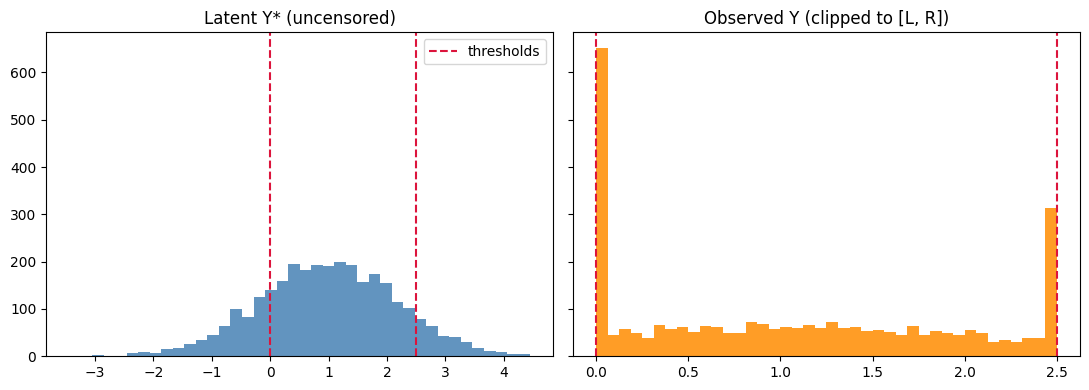

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].hist(y_star, bins=40, color='steelblue', alpha=0.85)
axes[0].set_title('Latent Y* (uncensored)')
axes[0].axvline(L, color='crimson', linestyle='--', label='thresholds')
axes[0].axvline(R, color='crimson', linestyle='--')
axes[0].legend()
axes[1].hist(y, bins=40, color='darkorange', alpha=0.85)
axes[1].set_title('Observed Y (clipped to [L, R])')
axes[1].axvline(L, color='crimson', linestyle='--')
axes[1].axvline(R, color='crimson', linestyle='--')
plt.tight_layout(); plt.show()

## Оценивание цензурированной регрессии

По умолчанию используется параметризация Олсена: в ней логарифм правдоподобия глобально вогнут [2], что гарантирует сходимость любого градиентного оптимизатора.

In [4]:
model = CensoredRegression(left=L, right=R).fit(
    X, y, feature_names=['x1', 'x2', 'x3']
)
print(model.summary())

                              Censored Regression Results                               
Dep. Variable:           y                   No. Observations:        3000
Model:                   CensoredRegression  Df Model:                4
Method:                  MLE                 Df Residuals:            2995
Date:                    Tue, 02 Jun 2026    Log-Likelihood:          -3831.9928
Time:                    19:52:42            LL-Null:                 -4286.2006
AIC:                     7673.9855           LLR p-value:             1.323e-196
BIC:                     7704.0174           Pseudo R-squ.:           0.1060
Left threshold:          0                   Right threshold:         2.5
                      coef     std err         z     P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
sigma               0.9959      0.0165   60.3216    0.0000      0.9635      1.0282
const               0.9963      0.0190   52.48

## Сравнение с методом наименьших квадратов

На цензурированных данных метод наименьших квадратов даёт смещённые оценки [4]: оценки коэффициентов смещаются к нулю примерно пропорционально вероятности цензурирования. Tobit-оценка по методу максимального правдоподобия в нашей реализации состоятельна.

In [5]:
X_with_int = np.column_stack([np.ones(n), X])
ols_beta, *_ = np.linalg.lstsq(X_with_int, y, rcond=None)

comparison = pd.DataFrame({
    'true':        beta_true,
    'OLS (biased)': ols_beta,
    'Censored MLE': model.coef_,
}, index=['const', 'x1', 'x2', 'x3'])
comparison['OLS bias']  = comparison['OLS (biased)']  - comparison['true']
comparison['MLE bias']  = comparison['Censored MLE']  - comparison['true']
comparison.round(4)

,true,OLS (biased),Censored MLE,OLS bias,MLE bias
const,1.0,1.0706,0.9963,0.0706,-0.0037
x1,0.5,0.3648,0.5126,-0.1352,0.0126
x2,-0.3,-0.1794,-0.2565,0.1206,0.0435
x3,0.2,0.1460,0.2030,-0.0540,0.0030


## Прогнозы: шесть величин одной командой

`model.predict(X)` возвращает DataFrame со всеми шестью величинами — тремя условными средними и тремя вероятностями: $P(Y=L)$, $P(L<Y<R)$ и $P(Y=R)$. У каждой колонки — однобуквенная мнемоника:

- `h` — *hidden*, латентное среднее $\mathbb E[Y^* \mid X] = X'\beta$
- `c` — *censored*, среднее $\mathbb E[Y \mid X]$
- `t` — *truncated*, среднее $\mathbb E[Y \mid X, L<Y<R]$
- `l` — вероятность того, что $Y$ примет значение $L$: $P(Y=L \mid X) = \Phi(\alpha_L)$
- `m` — вероятность того, что $Y$ попадёт внутрь интервала $(L, R)$: $P(L<Y<R \mid X) = \Phi(\alpha_R) - \Phi(\alpha_L)$
- `r` — вероятность того, что $Y$ примет значение $R$: $P(Y=R \mid X) = 1 - \Phi(\alpha_R)$

In [6]:
X_show = X[:6]
model.predict(X_show).round(3)   # default = all six columns

,latent,censored,truncated,prob_left,prob_interior,prob_right
0,0.143,0.470,0.816,0.443,0.548,0.009
1,1.489,1.438,1.351,0.067,0.778,0.155
2,0.704,0.831,1.023,0.240,0.725,0.036
3,0.800,0.901,1.062,0.211,0.745,0.044
4,1.018,1.068,1.152,0.153,0.778,0.068
5,0.896,0.974,1.101,0.184,0.762,0.054


Подмножество колонок задаётся теми же буквами. Например, только три вероятности (по построению их сумма равна 1) либо только латентное среднее как одномерный массив:

In [7]:
model.predict(X_show, kind='lmr').round(3)

,prob_left,prob_interior,prob_right
0,0.443,0.548,0.009
1,0.067,0.778,0.155
2,0.240,0.725,0.036
3,0.211,0.745,0.044
4,0.153,0.778,0.068
5,0.184,0.762,0.054


In [8]:
model.predict(X_show, kind='h')          # single letter -> 1-D ndarray

array([0.14305362, 1.48881203, 0.70415823, 0.80034359, 1.01807358,
       0.89647868])

Длинные имена — `kind='latent'`, `'censored'`, `'truncated'` — также допустимы и для обратной совместимости возвращают одномерный массив.

## Предельные эффекты через `get_margeff`

Интерфейс предельных эффектов повторяет `get_margeff` из statsmodels: один метод с параметрами — *где* считать (`at`) и *что* возвращать (`method`). Итоговая таблица оформлена в привычном для statsmodels виде.

In [9]:
# AME = average over the sample (at='overall'); statsmodels-style summary
print(model.get_margeff(at='overall', method='dydx', kind='censored').summary())

                     Censored Regression Marginal Effects                     
Dep. Variable:                      y
Method:                          dydx
At:                           overall
                   dy/dx    std err          z      P>|z|     [0.025     0.975]
------------------------------------------------------------------------------
x1                0.3600      0.012     30.227      0.000      0.337      0.383
x2               -0.1801      0.013    -14.113      0.000     -0.205     -0.155
x3                0.1426      0.013     10.805      0.000      0.117      0.168


Параметр `at` управляет точкой, в которой берётся производная: `at='overall'` соответствует *AME* (Average Marginal Effect) — предельный эффект вычисляется по каждому наблюдению и затем усредняется; `at='mean'` соответствует *MEM* (Marginal Effect at the Mean) — предельный эффект вычисляется один раз в точке средних значений регрессоров; `at='median'` — аналог *MEM* в точке медианных значений регрессоров. Ниже три варианта оценки **цензурированного** предельного эффекта сопоставляются с **латентным** предельным эффектом, который совпадает с самой оценкой коэффициента $\hat\beta_j$, поскольку $\partial\,\mathbb{E}[Y^* \mid X]/\partial X_j = \beta_j$ — это удобный ориентир: сравнение показывает, насколько сильно цензура «сжимает» предельный эффект относительно латентного.

In [10]:
import pandas as pd
summary = pd.DataFrame({
    'latent (=beta)':   model.get_margeff(at='overall', kind='latent').margeff,
    'censored AME':     model.get_margeff(at='overall', kind='censored').margeff,
    'censored MEM':     model.get_margeff(at='mean',    kind='censored').margeff,
    'truncated AME':    model.get_margeff(at='overall', kind='truncated').margeff,
}, index=['x1', 'x2', 'x3'])
summary.round(4)

,latent (=beta),censored AME,censored MEM,truncated AME
x1,0.5126,0.3600,0.3973,0.2005
x2,-0.2565,-0.1801,-0.1988,-0.1003
x3,0.2030,0.1426,0.1573,0.0794


Параметр `method` управляет видом эффекта. Помимо обычной производной (`dydx`) реализованы эластичность $\frac{\partial Y}{\partial X}\cdot\frac{X}{Y}$ (`eyex`) — она показывает, на сколько процентов изменится зависимая переменная $Y$ при изменении регрессора на один процент, — и две полуэластичности `dyex`, `eydx`, в которых процентное изменение применяется только к одной из переменных. Для дискретных регрессоров $0/1$ доступен `dummy=True`: тогда вместо производной возвращается разность значений $Y$ при $X=1$ и при $X=0$, что и является осмысленным «предельным эффектом» в бинарном случае.

In [11]:
elas = model.get_margeff(at='overall', method='eyex', kind='censored')
elas.summary_frame().round(4)

,eyex,std err,z,P>|z|,[0.025,0.975]
x1,-0.1238,0.0093,-13.3389,0.0,-0.1420,-0.1056
x2,-0.0317,0.0045,-7.0004,0.0,-0.0406,-0.0228
x3,-0.0193,0.0035,-5.4717,0.0,-0.0263,-0.0124


### Предельные эффекты вероятностей попадания в левую, внутреннюю и правую зоны

Помимо условного среднего можно вычислить, как регрессор влияет на три вероятности того, что $Y$ примет значение $L$ ($P(Y=L)=\Phi(\alpha_L)$), окажется внутри интервала ($P(L<Y<R)=\Phi(\alpha_R)-\Phi(\alpha_L)$) либо примет значение $R$ ($P(Y=R)=1-\Phi(\alpha_R)$). Эти эффекты задаются ключом `kind` со значениями `'prob-left'`, `'prob-interior'`, `'prob-right'`. Поскольку три вероятности в сумме дают единицу, их предельные эффекты по построению складываются в ноль.

In [12]:
prob_effects = pd.DataFrame({
    'P(Y=L)':     model.get_margeff(kind='prob-left').margeff,
    'P(L<Y<R)':   model.get_margeff(kind='prob-interior').margeff,
    'P(Y=R)':     model.get_margeff(kind='prob-right').margeff,
}, index=['x1', 'x2', 'x3'])
prob_effects['sum (=0)'] = prob_effects.sum(axis=1)
prob_effects.round(4)

,P(Y=L),P(L<Y<R),P(Y=R),sum (=0)
x1,-0.1221,0.0461,0.0760,0.0
x2,0.0611,-0.0231,-0.0380,0.0
x3,-0.0484,0.0183,0.0301,0.0


Положительный коэффициент перемещает наблюдения от левого порога к правому: эффект на $P(Y=L)$ отрицателен, на $P(Y=R)$ — положителен. Столбец `sum (=0)` подтверждает, что ограничение «сумма равна нулю» выполняется численно.

## Тест отношения правдоподобия

Проверим, нужен ли регрессор `x3`: оценим модель с дополнительным ограничением $\beta_{x_3}=0$ и сравним логарифмы правдоподобия с полной моделью.

In [13]:
restricted = CensoredRegression(left=L, right=R).fit(X[:, :2], y)
res = lr_test(model, restricted)
print(res)

Likelihood-ratio test
  LR statistic : 111.3544
  df           : 1
  p-value      : 4.949e-26
  log-lik full : -3831.9928
  log-lik rest.: -3887.6700
  n            : 3000


Малое p-value отвергает ограничение, то есть переменную `x3` нельзя считать избыточной. В рассматриваемом процессе генерации данных истинный коэффициент при `x3` равен 0.2, а выборка велика, поэтому тест корректно отвергает гипотезу.

### LR-тест с гипотезой в виде строки

Перерасчёт ограниченной модели вручную удобен лишь в простых случаях вроде «исключить одну колонку». Для совместных или составных линейных ограничений `model.lr_test(hypotheses)` копирует интерфейс `f_test` из statsmodels: принимает линейное ограничение строкой — одиночное, совместное или с арифметическими выражениями от имён параметров.

In [14]:
# Drop a single regressor (same null as the two-model test above)
print(model.lr_test('x3 = 0'))

Likelihood-ratio test
  LR statistic : 111.3544
  df           : 1
  p-value      : 4.949e-26
  log-lik full : -3831.9928
  log-lik rest.: -3887.6700
  n            : 3000


In [15]:
# Joint restriction: x2 AND x3 are zero (composite null)
print(model.lr_test('(x2 = 0), (x3 = 0)'))

Likelihood-ratio test
  LR statistic : 286.4290
  df           : 2
  p-value      : 6.35e-63
  log-lik full : -3831.9928
  log-lik rest.: -3975.2073
  n            : 3000


In [16]:
# Composite restriction with arithmetic: x1 - 2*x2 = 0
# (equivalent to testing whether x1 equals twice x2)
print(model.lr_test('x1 - 2*x2 = 0'))

Likelihood-ratio test
  LR statistic : 549.6200
  df           : 1
  p-value      : 1.523e-121
  log-lik full : -3831.9928
  log-lik rest.: -4106.8028
  n            : 3000


При каждом вызове задача оптимизации решается заново с линейным ограничением $R\hat\theta = r$ (через `scipy.optimize` и `LinearConstraint`), а в качестве результата возвращается асимптотическая LR-статистика $2(\ell_{\text{full}} - \ell_{\text{rest.}})\sim \chi^2_q$.

---

### 3.2.2 Классический Tobit на данных Fair о супружеских изменах

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from censtrunc import CensoredRegression

data = sm.datasets.fair.load_pandas().data
print('n =', len(data))
print(f"share with affairs == 0: {(data['affairs'] == 0).mean():.1%}")
data.head()

n = 6366
share with affairs == 0: 67.8%


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


## Спецификация

Датасет Fair [5] содержит данные опроса 1969 года: 6366 респондентов указали число случаев супружеской измены за прошлый год вместе с набором демографических и семейных характеристик. Зависимая переменная цензурирована слева в нуле (около 68% респондентов сообщили о нулевом числе случаев). Следуя оригинальной работе, построим регрессию числа случаев измены от стандартного набора демографических и семейных признаков.

In [2]:
covariates = ['rate_marriage', 'age', 'yrs_married', 'children',
              'religious', 'educ', 'occupation', 'occupation_husb']
X = data[covariates]
y = data['affairs']

## Оценивание

Левый порог `CensoredRegression` равен нулю; правый порог не задаётся.

In [3]:
model = CensoredRegression(left=0.0).fit(X, y)
print(model.summary())

                              Censored Regression Results                               
Dep. Variable:           y                   No. Observations:        6366
Model:                   CensoredRegression  Df Model:                9
Method:                  MLE                 Df Residuals:            6356
Date:                    Tue, 02 Jun 2026    Log-Likelihood:          -7804.3803
Time:                    19:52:44            LL-Null:                 -8155.0240
AIC:                     15628.7605          LLR p-value:             3.780e-146
BIC:                     15696.3478          Pseudo R-squ.:           0.0430
Left threshold:          0                   Right threshold:         none
                      coef     std err         z     P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
sigma               4.4990      0.0771   58.3463    0.0000      4.3478      4.6501
const               7.8354      0.7135   10.9

## Предельные эффекты

Поскольку зависимая переменная цензурирована слева на нуле, цензурированные предельные эффекты по модулю меньше латентных. Латентные (нецензурированные) коэффициенты относятся к латентной величине $Y^*$ — ненаблюдаемой количественной мере склонности к измене; цензурированные предельные эффекты относятся к ожидаемому числу измен — наблюдаемой величине.

In [4]:
ame_cens = model.ame(kind='censored').to_dataframe()
ame_lat  = model.ame(kind='latent').to_dataframe()
pd.concat([
    ame_lat[['dy/dx']].rename(columns={'dy/dx': 'latent'}),
    ame_cens[['dy/dx', 'std err', 'P>|z|']].rename(columns={'dy/dx': 'censored E[Y]'}),
], axis=1).round(4)

,latent,censored E[Y],std err,P>|z|
rate_marriage,-1.5313,-0.4326,0.0213,0.0000
age,-0.1051,-0.0297,0.0070,0.0000
yrs_married,0.1282,0.0362,0.0074,0.0000
children,-0.0276,-0.0078,0.0218,0.7206
religious,-0.9434,-0.2665,0.0243,0.0000
educ,-0.0857,-0.0242,0.0106,0.0228
occupation,0.3125,0.0883,0.0232,0.0001
occupation_husb,0.0143,0.0040,0.0157,0.7966


## Проверка с методом наименьших квадратов

На цензурированной выборке метод наименьших квадратов занижает оценки коэффициентов [4]; оценка модели Tobit методом максимального правдоподобия это смещение устраняет.

In [5]:
X_int = sm.add_constant(X)
ols = sm.OLS(y, X_int).fit()
pd.DataFrame({
    'OLS coef':    ols.params.values,
    'Tobit coef':  model.coef_,
}, index=ols.params.index).round(4)

,OLS coef,Tobit coef
const,3.6235,7.8354
rate_marriage,-0.4205,-1.5313
age,-0.0146,-0.1051
yrs_married,-0.0160,0.1282
children,-0.0171,-0.0276
religious,-0.2437,-0.9434
educ,-0.0174,-0.0857
occupation,0.0658,0.3125
occupation_husb,0.0040,0.0143


---

### 3.2.3 Усечённая регрессия

In [1]:
import numpy as np
import pandas as pd
from censtrunc import TruncatedRegression

rng = np.random.default_rng(7)
n_population = 8000

## Моделирование усечённой выборки

Сгенерируем большую генеральную совокупность и оставим только наблюдения с $0 < Y^* < 2.5$. В рассматриваемом процессе генерации данных двустороннее усечение «переживают» около 60 % исходных наблюдений.

In [2]:
X_pop = rng.normal(size=(n_population, 2))
beta_true = np.array([1.0, 0.5, -0.3])
y_star = beta_true[0] + X_pop @ beta_true[1:] + rng.normal(scale=1.0, size=n_population)
L, R = 0.0, 2.5
mask = (y_star > L) & (y_star < R)
X = X_pop[mask]
y = y_star[mask]
print(f'Observed after truncation: {len(y)} / {n_population}')

Observed after truncation: 5741 / 8000


## Оценивание усечённой регрессии

In [3]:
model = TruncatedRegression(left=L, right=R).fit(
    X, y, feature_names=['x1', 'x2']
)
print(model.summary())

                              Truncated Regression Results                              
Dep. Variable:           y                   No. Observations:        5741
Model:                   TruncatedRegression Df Model:                3
Method:                  MLE                 Df Residuals:            5737
Date:                    Tue, 02 Jun 2026    Log-Likelihood:          -4830.9612
Time:                    19:52:46            LL-Null:                 -5136.1192
AIC:                     9669.9225           LLR p-value:             2.962e-133
BIC:                     9696.5440           Pseudo R-squ.:           0.0594
Left truncation:         0                   Right truncation:        2.5
                      coef     std err         z     P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
sigma               0.9944      0.0316   31.5070    0.0000      0.9326      1.0563
const               0.9946      0.0245   40.67

## Сравнение: МНК на усечённой выборке смещён

Метод наименьших квадратов на усечённой выборке трактует её как обычную выборку из неограниченной генеральной совокупности — в итоге оценки коэффициентов смещены и, как правило, сжаты к нулю.

In [4]:
X_int = np.column_stack([np.ones(len(y)), X])
ols_beta, *_ = np.linalg.lstsq(X_int, y, rcond=None)

comparison = pd.DataFrame({
    'true':         beta_true,
    'OLS (biased)': ols_beta,
    'Truncated MLE': model.coef_,
}, index=['const', 'x1', 'x2'])
comparison['OLS bias']           = comparison['OLS (biased)']  - comparison['true']
comparison['Truncated MLE bias'] = comparison['Truncated MLE'] - comparison['true']
comparison.round(4)

,true,OLS (biased),Truncated MLE,OLS bias,Truncated MLE bias
const,1.0,1.1475,0.9946,0.1475,-0.0054
x1,0.5,0.1952,0.4881,-0.3048,-0.0119
x2,-0.3,-0.1241,-0.3105,0.1759,-0.0105


## Прогнозы

Для усечённой модели содержательный смысл имеют только две величины — точечных масс на порогах нет, и столбцы для вероятностей $P(Y=L)$, $P(L<Y<R)$, $P(Y=R)$ неприменимы:

- `h` (`latent`): $X'\hat\beta$ — среднее в генеральной совокупности
- `t` (`truncated`): $\mathbb E[Y | X, L < Y < R]$

In [5]:
preds = model.predict(X[:6])      # default = 'ht' -> both columns
preds.insert(0, 'observed', y[:6])
preds.round(3)

,observed,latent,truncated
0,1.590,0.902,1.104
1,0.317,1.137,1.202
2,1.514,1.081,1.178
3,1.376,0.947,1.122
4,1.085,0.764,1.047
5,0.074,0.481,0.936


---

### 3.2.4 Иллюстрация: усечение и цензура на одном процессе

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from censtrunc import CensoredRegression, TruncatedRegression
from censtrunc._means import value_for_kind
from censtrunc._utils import _prepare_design_matrix

rng = np.random.default_rng(2026)
n = 250
x = rng.uniform(-10, 10, size=n)
sigma_true = 2.0
y_star = 1.0 * x + rng.normal(scale=sigma_true, size=n)
L, R = -5.0, 5.0

Чтобы наглядно сопоставить два режима наблюдения: усечение и цензуру — генерируется единый латентный процесс $Y^* = X + e$. **Усечённая выборка:** наблюдения с $y \notin (L, R)$ полностью исключены. **Цензурированная выборка:** те же наблюдения заменены ближайшей границей. Линейная зависимость $Y^* = X$ в обоих случаях одна и та же. Простой вид $Y^* = X$ выбран для наглядности графика; результаты переносятся на любую линейную спецификацию. Сравнение на двух соседних подграфиках позволяет проиллюстрировать различия в формах смещения, которые в численных таблицах незаметны.

In [2]:
mask = (y_star > L) & (y_star < R)
x_t, y_t = x[mask], y_star[mask]
x_c, y_c = x.copy(), np.clip(y_star, L, R)

mt = TruncatedRegression(left=L, right=R).fit(x_t.reshape(-1, 1), y_t)
mc = CensoredRegression(left=L, right=R).fit(x_c.reshape(-1, 1), y_c)
print(f'truncated:  n={len(y_t)}, beta_hat = {mt.coef_.round(3)}')
print(f'censored:   n={len(y_c)}, beta_hat = {mc.coef_.round(3)}')

truncated:  n=146, beta_hat = [-0.003  0.946]
censored:   n=250, beta_hat = [0.059 0.939]


Построим доверительную полосу прогнозов с учётом асимптотической неопределённости оценок параметров. Возьмём 200 векторов параметров из их асимптотического нормального распределения, для каждого вычислим кривую условного среднего и нарисуем эти 200 кривых полупрозрачными. Скопления на порогах цензурирования выделены красным на правом графике.

In [3]:
def prediction_band(model, x_grid, kind, n_draws=200, seed=0):
    rng = np.random.default_rng(seed)
    samples = rng.multivariate_normal(model.params_, model.cov_params_, size=n_draws)
    samples = samples[samples[:, 0] > 0]   # keep only feasible sigma > 0
    Xg, _ = _prepare_design_matrix(x_grid.reshape(-1, 1), fit_intercept=True)
    curves = np.empty((samples.shape[0], x_grid.size))
    for i, theta in enumerate(samples):
        sigma, beta = theta[0], theta[1:]
        curves[i] = value_for_kind(
            beta, sigma, Xg,
            model._left, model._right, model._has_left, model._has_right, kind,
        )
    return curves

x_grid = np.linspace(-10, 10, 300)
curves_t = prediction_band(mt, x_grid, kind='truncated')
curves_c = prediction_band(mc, x_grid, kind='censored')

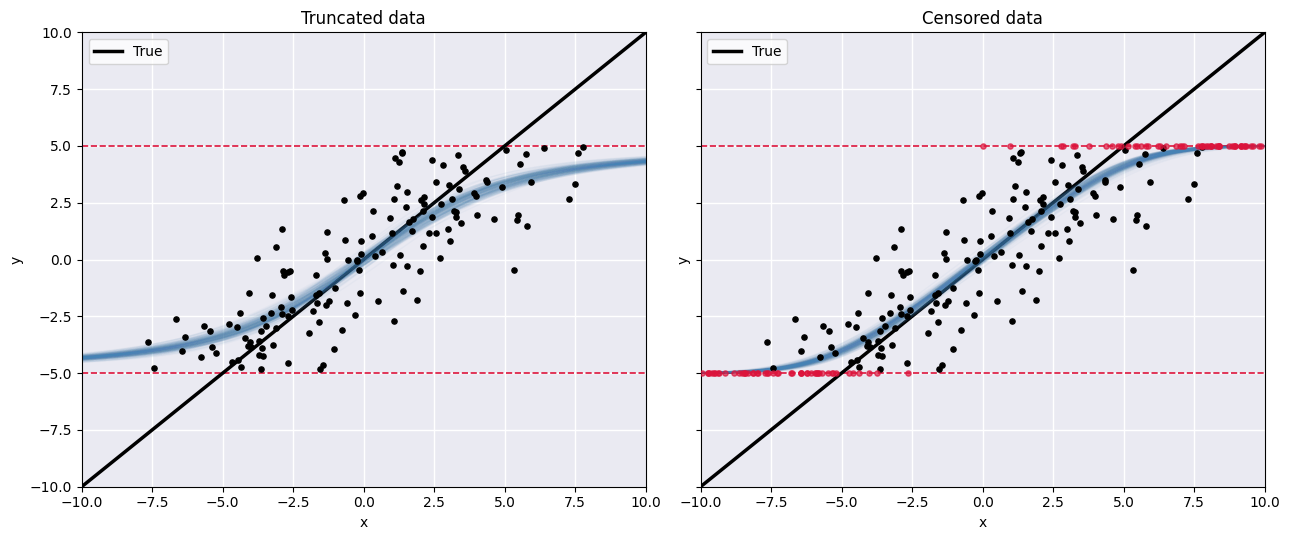

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax in axes:
    ax.set_facecolor('#eaeaf2')
    ax.grid(True, color='white', linewidth=1)
    ax.axhline(L, color='crimson', linestyle='--', linewidth=1.2)
    ax.axhline(R, color='crimson', linestyle='--', linewidth=1.2)
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.plot(x_grid, x_grid, color='black', linewidth=2.5, label='True')

# Left panel: truncated
ax = axes[0]
ax.set_title('Truncated data')
for c in curves_t:
    ax.plot(x_grid, c, color='steelblue', alpha=0.04, linewidth=1)
ax.scatter(x_t, y_t, c='black', s=14, zorder=5)
ax.legend(loc='upper left')

# Right panel: censored
ax = axes[1]
ax.set_title('Censored data')
for c in curves_c:
    ax.plot(x_grid, c, color='steelblue', alpha=0.04, linewidth=1)
is_at_bound = (y_c == L) | (y_c == R)
ax.scatter(x_c[~is_at_bound], y_c[~is_at_bound], c='black', s=14, zorder=5)
ax.scatter(x_c[is_at_bound],  y_c[is_at_bound],  c='crimson', s=14, zorder=5, alpha=0.7)
ax.legend(loc='upper left')

plt.tight_layout(); plt.show()

**На что обратить внимание.**

- Чёрная линия — истинная зависимость $Y^* = X$.
- Синяя полоса — оценённый методом максимального правдоподобия прогноз условного среднего с учётом асимптотической неопределённости оценок параметров. На **левом** подграфике оценённое условное среднее отклоняется внутрь интервала $(L, R)$, поскольку усечённое среднее $\mathbb E[Y \mid X, L<Y<R]$ смещается к центру интервала; на **правом** подграфике оценка становится более пологой у порогов, так как цензурированное среднее $\mathbb E[Y\mid X]$ совмещает латентную линейную часть с точечными массами.
- Красные точки на правом подграфике — цензурированные наблюдения, попавшие на $Y=L$ и $Y=R$. В усечённой выборке аналогичных наблюдений нет, поскольку при усечении они полностью исключены.
- Оценённые кривые близки к истинной во внутренней области, где данных больше всего; у обеих падает точность вблизи и за порогами, но ни одна не испытывает столь сильного смещения оценок к нулю, как метод наименьших квадратов.

---

## 3.3 Эмпирическая проверка корректности

Три независимые проверки оценки максимального правдоподобия в цензурированной модели:

1. **Предел без цензуры** — если пороги отодвинуть за пределы диапазона данных, ни одно наблюдение не попадает под цензуру, и оценка должна совпасть с оценкой методом наименьших квадратов.
2. **Предел probit** — при $L \approx R$ цензурированный логарифм правдоподобия сводится к probit-правдоподобию для индикатора $\mathbf 1\{Y^* > c\}$, причём оценки коэффициентов связаны соотношением $\hat\beta_{\text{probit}} = \hat\beta_{\text{tobit}}/\hat\sigma_{\text{tobit}}$ [10, §27.4].
3. **Кросс-валидация с R** — пакет `survival::survreg` (на нём построен `AER::tobit`) и `truncreg::truncreg` решают ту же задачу максимизации правдоподобия. Две корректные реализации должны прийти в одну и ту же точку с точностью оптимизатора.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from censtrunc import CensoredRegression, TruncatedRegression

rng = np.random.default_rng(0)
n = 1000
X = rng.normal(size=(n, 3))
y = 2.0 + 1.5*X[:,0] - 0.7*X[:,1] + 0.3*X[:,2] + rng.normal(scale=1.3, size=n)

## Без цензуры $\Rightarrow$ МНК

Возьмём `left=-1e6`, `right=1e6` — ни одно наблюдение не попадёт под цензуру. Цензурированный логарифм правдоподобия в этом пределе сводится к гауссовому, а его максимум совпадает с оценкой по методу наименьших квадратов.

In [2]:
ols = sm.OLS(y, sm.add_constant(X)).fit()
cens = CensoredRegression(left=-1e6, right=1e6).fit(X, y)
trunc = TruncatedRegression(left=-1e6, right=1e6).fit(X, y)

pd.DataFrame({
    'OLS':            np.asarray(ols.params),
    'Censored MLE':   cens.coef_,
    'Truncated MLE':  trunc.coef_,
}, index=['const', 'x1', 'x2', 'x3']).round(6)

,OLS,Censored MLE,Truncated MLE
const,2.046512,2.046482,2.046512
x1,1.434191,1.434221,1.434191
x2,-0.626598,-0.626603,-0.626598
x3,0.345980,0.345982,0.345980


Значения в колонках совпадают до нескольких знаков. Дополнительно измерим максимальное расхождение и проверим, совпадают ли оценки параметра масштаба и логарифма правдоподобия. Используется оценка масштаба методом максимального правдоподобия $\hat\sigma = \sqrt{\mathrm{SSR}/n}$, где ${\mathrm{SSR}}$ — сумма квадратов остатков (sum of squared residuals).

In [3]:
ols_beta = np.asarray(ols.params)
print(f'max |beta_censored - beta_OLS|  = {np.max(np.abs(cens.coef_ - ols_beta)):.2e}')
print(f'max |beta_truncated - beta_OLS| = {np.max(np.abs(trunc.coef_ - ols_beta)):.2e}')
print(f'|sigma_censored - sqrt(SSR/n)|  = {abs(cens.sigma_ - np.sqrt(ols.ssr/n)):.2e}')
print(f'|loglik_censored - loglik_OLS|  = {abs(cens.llf_ - ols.llf):.2e}')

max |beta_censored - beta_OLS|  = 3.00e-05
max |beta_truncated - beta_OLS| = 4.44e-16
|sigma_censored - sqrt(SSR/n)|  = 7.55e-07
|loglik_censored - loglik_OLS|  = 5.90e-07


Все расхождения — в пределах погрешности численного оптимизатора. В отсутствие цензуры оценщик сводится к методу наименьших квадратов, как и должно быть; следовательно, логарифм правдоподобия и его оптимизация реализованы корректно.

## С цензурой: совпадение с R и расхождение с МНК

В этом разделе используем явно цензурированные данные. Для каждого коэффициента сравниваются четыре числа:

- **true** — истинное значение из процесса генерации данных;
- **censtrunc** — оценка методом максимального правдоподобия из нашего пакета;
- **R survreg** — гауссова реализация в `survreg` (на ней построен `AER::tobit`), посчитанная полностью независимым кодом;
- **OLS** — оценка методом наименьших квадратов, смещённая при цензуре.

Две корректные реализации оценки максимального правдоподобия должны прийти к *одному и тому же* единственному максимуму, так что оценки из `censtrunc` и из R должны совпадать с точностью оптимизатора, а оценка наименьших квадратов — отличаться от обеих и быть смещённой.

In [4]:
import shutil, subprocess, json, tempfile, os
from pathlib import Path

rng2 = np.random.default_rng(20260527)
nc = 4000
Xc = rng2.normal(size=(nc, 2))
y_star_c = 1.0 + 0.7*Xc[:, 0] - 0.4*Xc[:, 1] + rng2.normal(size=nc)
Lc, Rc = 0.0, 2.5
yc = np.clip(y_star_c, Lc, Rc)

cens = CensoredRegression(left=Lc, right=Rc).fit(Xc, yc)
ols_c = np.asarray(sm.OLS(yc, sm.add_constant(Xc)).fit().params)

# Run R's survreg via the bundled reference script, if R is available.
def _find_r_script():
    for c in [Path('tests/reference/fit_tobit.R'),
              Path('../tests/reference/fit_tobit.R')]:
        if c.exists():
            return c
    return None

r_beta = r_sigma = None
rscript, script_path = shutil.which('Rscript'), _find_r_script()
if rscript and script_path:
    fd, csvp = tempfile.mkstemp(suffix='.csv'); os.close(fd)
    np.savetxt(csvp, np.column_stack([yc, Xc]), delimiter=',', header='y,x1,x2', comments='')
    try:
        out = subprocess.run([rscript, str(script_path), csvp, str(Lc), str(Rc)],
                             capture_output=True, text=True, timeout=120, check=True)
        rt = json.loads(out.stdout)['tobit']
        r_beta = np.array([rt['coef']['(Intercept)'], rt['coef']['x1'], rt['coef']['x2']])
        r_sigma = float(rt['scale'])
    except Exception:
        r_beta = None
    finally:
        os.remove(csvp)

In [5]:
if r_beta is not None:
    table = pd.DataFrame({
        'true':         [1.0, 0.7, -0.4],
        'censtrunc':    cens.coef_,
        'R survreg':    r_beta,
        'OLS (biased)': ols_c,
    }, index=['const', 'x1', 'x2'])
    display(table.round(6))
    print(f'max |censtrunc - R|  = {np.max(np.abs(cens.coef_ - r_beta)):.2e}  (independent solvers, same optimum)')
    print(f'|sigma_censtrunc - sigma_R| = {abs(cens.sigma_ - r_sigma):.2e}')
    print(f'max |censtrunc - OLS| = {np.max(np.abs(cens.coef_ - ols_c)):.3f}  (Tobit correction is real)')
else:
    print('R not available at build time.')
    print('The live comparison runs in the test suite: tests/test_r_reference.py')
    print('censtrunc estimates:', cens.coef_.round(4))
    print('OLS (biased):       ', ols_c.round(4))

,true,censtrunc,R survreg,OLS (biased)
const,1.0,1.014284,1.014284,1.090364
x1,0.7,0.701331,0.701331,0.470177
x2,-0.4,-0.410105,-0.410105,-0.277838


max |censtrunc - R|  = 3.05e-08  (independent solvers, same optimum)
|sigma_censtrunc - sigma_R| = 2.41e-08
max |censtrunc - OLS| = 0.231  (Tobit correction is real)


Значения в столбцах `censtrunc` и `R` совпадают примерно до шести знаков, и при этом $\max|\text{censtrunc} - R|$ — малое ненулевое число порядка $10^{-8}$: два независимых оптимизатора сошлись к одному и тому же максимуму, оставаясь не побитово идентичными. Обе оценки приближаются к истинным значениям коэффициентов, тогда как оценка наименьших квадратов заметно смещена к нулю — это и есть известное сжатие оценок при цензуре, описанное в [4].

## Предел probit: при узких порогах Tobit сводится к probit

Возьмём цензурированную регрессию с $L = R = c$. Когда наблюдения внутри интервала $(L, R)$ отсутствуют, логарифм правдоподобия приводится к виду

$$\ell(\beta, \sigma) = \sum_i \mathbf 1\{y_i = c\}\,\log\Phi\!\left(\tfrac{c - X_i'\beta}{\sigma}\right) +\mathbf 1\{y_i > c\}\,\log\!\left[1 - \Phi\!\left(\tfrac{c - X_i'\beta}{\sigma}\right)\right],$$

а это в точности логарифм правдоподобия probit для индикатора $D_i = \mathbf 1\{Y^*_i > c\}$. При этом параметры probit-модели совпадают с приведёнными к единичной дисперсии параметрами Tobit-модели: $\beta_{\text{probit}} = \beta_{\text{tobit}}/\sigma_{\text{tobit}}$ [10, §27.4].

Положить $L = R$ буквально нельзя — при отсутствии внутреннего интервала параметр $\sigma$ перестаёт быть отдельно идентифицируемым. Однако достаточно узкого интервала вокруг $c$ — $[c - \varepsilon, c + \varepsilon]$ — чтобы немногочисленные внутренние наблюдения восстановили идентификацию $\sigma$, а остальные данные вели себя как бинарный исход. При $\varepsilon\to 0$ должно выполняться $\hat\beta_{\text{tobit}}/\hat\sigma_{\text{tobit}}\to \hat\beta_{\text{probit}}$.

In [6]:
from statsmodels.discrete.discrete_model import Probit

rng3 = np.random.default_rng(20250601)
n3 = 8000
Xp = rng3.normal(size=(n3, 2))
beta_p = np.array([0.4, 1.2, -0.8])
y_star_p = beta_p[0] + Xp @ beta_p[1:] + rng3.normal(size=n3)
y_bin = (y_star_p > 0.0).astype(float)
probit = Probit(y_bin, sm.add_constant(Xp)).fit(disp=False)

def fit_band(eps: float):
    y_obs = np.clip(y_star_p, -eps, eps)
    m = CensoredRegression(left=-eps, right=eps).fit(Xp, y_obs)
    return m.coef_ / m.sigma_   # the ratio that should match probit

table = pd.DataFrame({
    'probit beta':                     np.asarray(probit.params),
    'tobit / sigma  (eps=0.5)':        fit_band(0.50),
    'tobit / sigma  (eps=0.1)':        fit_band(0.10),
    'tobit / sigma  (eps=0.05)':       fit_band(0.05),
}, index=['const', 'x1', 'x2'])
table.round(4)

,probit beta,tobit / sigma (eps=0.5),tobit / sigma (eps=0.1),tobit / sigma (eps=0.05)
const,0.3791,0.3755,0.3728,0.3744
x1,1.2218,1.1923,1.2134,1.2192
x2,-0.7774,-0.7726,-0.7754,-0.7783


По мере сужения интервала $[c-\varepsilon, c+\varepsilon]$ отношение оценок Tobit-модели к оценке масштаба приближается к probit-оценке. Оценка свободного члена смещается сильнее, чем оценки коэффициентов при регрессорах — это эффект, обусловленный конечной шириной интервала, величина которого имеет порядок $\varepsilon/\sigma$. Уже при $\varepsilon = 0.05$ оценки коэффициентов согласуются с probit-оценками с точностью до нескольких процентов. Тем самым проверяется и часть формулы правдоподобия, отвечающая за граничные члены, помимо проверки «без цензуры», сделанной выше.

---

# Часть Б. Модель Хекмана

## 4.1 Теория

### Задача с отбором

Пусть зависимая переменная $Y$ наблюдается только тогда, когда индивид *попадает* в выборку по ненаблюдаемому правилу. Классический пример — уравнение зарплаты. В качестве зависимой переменной берётся не сама зарплата $W$, а её логарифм $Y = \log W$: это стандартный приём, предложенный Минсером [11]. Логарифм зарплаты наблюдается лишь у занятых. Общая модель имеет вид (в уравнении зарплаты $Y^*$ — латентный $\log W$, наблюдаемый только у занятых)

$$
Y^* = X'\beta + e, \qquad S^* = Z'\gamma + u, \qquad S = \mathbf 1\{S^* > 0\},
$$
$$Y = Y^* \text{ при } S = 1, \text{ иначе не наблюдается}, \qquad
(e, u) \sim \mathcal N\!\left(0,
 \begin{pmatrix}\sigma^2 & \rho\sigma \\ \rho\sigma & 1\end{pmatrix}\right).$$

Дисперсия $u$ нормирована на единицу для идентифицируемости (стандартное probit-соглашение). При $\rho \ne 0$ оценка методом наименьших квадратов на отобранной подвыборке оказывается смещённой, поскольку

$$\mathbb E[Y \mid X, Z, S=1] = X'\beta + \rho\sigma\,\lambda(Z'\gamma),$$

где $\lambda(t) = \phi(t)/\Phi(t)$ — обратный коэффициент Миллса. Если опустить $\lambda(Z'\gamma)$ в регрессии (как делает обычный метод наименьших квадратов), получается классическое смещение из-за пропущенной переменной.

### Двухшаговый алгоритм Хекмана

1. **Probit-регрессия** $S$ по $Z$ даёт оценку $\hat\gamma$.
2. **Обратный коэффициент Миллса** $\hat\lambda_i = \phi(Z_i'\hat\gamma)/\Phi(Z_i'\hat\gamma)$ вычисляется для отобранных наблюдений.
3. **Регрессия методом наименьших квадратов** $y_i$ по $(X_i, \hat\lambda_i)$ на отобранной подвыборке даёт оценки $\hat\beta$ и $\hat\rho\hat\sigma$.

Стандартные ошибки второго шага без коррекции занижены: они игнорируют дисперсию $\hat\gamma$, привносимую probit-шагом. Парный бутстрап (`model.bootstrap`) восполняет этот пробел.

### Совместная оценка методом максимального правдоподобия

Полный логарифм правдоподобия [10, §27.10]:

$$\begin{aligned}
\ell &= \sum_{S_i=0} \log\bigl[1 - \Phi(Z_i'\gamma)\bigr] \\
&\quad + \sum_{S_i=1}\!\bigg\{\log\Phi\!\left(\frac{Z_i'\gamma + (\rho/\sigma)(Y_i - X_i'\beta)}{\sqrt{1 - \rho^2}}\right) \\
&\hspace{6.5em} - \tfrac12\log(2\pi\sigma^2) - \frac{(Y_i - X_i'\beta)^2}{2\sigma^2}\bigg\}.
\end{aligned}$$

Оценка асимптотически эффективна, но несколько медленнее двухшагового алгоритма. Внутренняя оптимизация использует $\rho = \tanh(\eta)$, чтобы условие $|\rho| < 1$ не требовало явного ограничения.

### Шесть прогнозных величин

`HeckitRegression.predict()` возвращает шесть величин через однобуквенный код `kind`; по умолчанию `'snpohu'` возвращает все шесть в виде DataFrame.

**Уравнение отбора** (использует $Z$):

- **`s`** — вероятность отбора в выборку $\Phi(Z'\hat\gamma)$
- **`n`** — вероятность не попасть в выборку $1 - \Phi(Z'\hat\gamma)$
- **`p`** — латентная переменная $Z'\hat\gamma$

**Уравнение исхода** (использует $X$, иногда $Z$):

- **`o`** — условное среднее у отобранных наблюдений $\mathbb E[Y \mid X, Z, S=1] = X'\hat\beta + \hat\rho\hat\sigma\,\lambda(Z'\hat\gamma)$
- **`h`** — латентное безусловное среднее $\mathbb E[Y^* \mid X] = X'\hat\beta$
- **`u`** — условное среднее у неотобранных наблюдений $\mathbb E[Y^* \mid X, Z, S=0] = X'\hat\beta - \hat\rho\hat\sigma\,\phi(Z'\hat\gamma)/[1-\Phi(Z'\hat\gamma)]$

### Предельные эффекты

Четыре стандартных вида предельных эффектов [9, §19.5] доступны через `model.get_margeff(kind=...)`:

| `kind` | Differentiates |
|---|---|
| `'latent'` | $E[Y^*\mid X] = X'\beta$ |
| `'conditional'` | $E[Y\mid X, Z, S=1] = X'\beta + \rho\sigma\,\lambda(Z'\gamma)$ |
| `'unconditional'` | $E[Y\cdot S\mid X, Z] = \Phi(Z'\gamma)X'\beta + \rho\sigma\,\phi(Z'\gamma)$ |
| `'prob-selected'` | $P(S=1\mid Z) = \Phi(Z'\gamma)$ |

При $\delta(t) = \lambda(t)(t + \lambda(t))$ (так что $\mathrm d\lambda/\mathrm dt = -\delta$) частная производная условного среднего по переменной $v$ имеет вид

$$\frac{\partial E[Y\mid S=1]}{\partial v} = \beta_v\,\mathbf 1\{v\in X\} \;-\; \gamma_v\,\rho\sigma\,\delta(Z'\gamma)\,\mathbf 1\{v\in Z\}.$$

Переменные, входящие в оба уравнения (идентифицируются по совпадению имён), дают вклад в предельный эффект и со стороны X, и со стороны Z; обе составляющие складываются. Стандартные ошибки получаются дельта-методом по оцененной совместной ковариационной матрице.

## 4.2 Применение

Демонстрация на симулированных данных, а затем — на классическом наборе Mroz [6]. Это данные опроса 1976 года о 753 замужних женщинах; 428 из них экономически активны, у остальных 325 зарплата отсутствует. Ниже показано: как получать оценки двухшаговым методом и совместным методом максимального правдоподобия, как запрашивать шесть прогнозных величин, как пользоваться формулами в стиле patsy, как получать корректные стандартные ошибки двухшаговой оценки парным бутстрапом и как читать таблицу предельных эффектов.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from censtrunc import HeckitRegression

rng = np.random.default_rng(42)
n = 4000
# Shared regressor (in both equations); two exclusive regressors
shared  = rng.normal(size=n)
x_only  = rng.normal(size=n)       # in the outcome eq. only
z_only  = rng.normal(size=n)       # in the selection eq. only (exclusion)

beta_true  = np.array([1.0,  0.5, -0.3])     # const, shared, x_only
gamma_true = np.array([0.0,  0.3,  0.6])     # const, shared, z_only
rho_true, sigma_true = 0.6, 1.0

Sigma = np.array([[sigma_true**2, rho_true*sigma_true],
                  [rho_true*sigma_true, 1.0]])
errs = rng.multivariate_normal([0.0, 0.0], Sigma, size=n)
e, u = errs[:, 0], errs[:, 1]

X = np.column_stack([shared, x_only])
Z = np.column_stack([shared, z_only])
S = (gamma_true[0] + Z @ gamma_true[1:] + u > 0).astype(int)
y_full = beta_true[0] + X @ beta_true[1:] + e
y = np.where(S == 1, y_full, np.nan)
print(f'Selected (S=1): {S.sum()} / {n}  ({S.mean():.1%})')

Selected (S=1): 2022 / 4000  (50.5%)


## Почему OLS на отобранной подвыборке смещён

При $\rho > 0$ ошибки $u$ и $e$ коррелированы, поэтому наблюдения с высоким $e$ в среднем имеют высокий $u$ и потому чаще попадают в выборку. Условное среднее на отобранных наблюдениях принимает вид

$$\mathbb E[Y \mid X, S = 1] = X'\beta + \rho\sigma\,\lambda(Z'\gamma),$$

где $\lambda(\cdot)$ — обратный коэффициент Миллса. Если опустить $\lambda(Z'\gamma)$ в регрессии (как делает наивный OLS), получается классическое смещение из-за пропущенной переменной.

In [2]:
sel = ~np.isnan(y)
X_full = sm.add_constant(X)
ols = sm.OLS(y[sel], X_full[sel]).fit()
print('OLS on selected subsample (biased):')
print(np.asarray(ols.params).round(4))
print('truth:', beta_true)

OLS on selected subsample (biased):
[ 1.3651  0.4366 -0.3037]
truth: [ 1.   0.5 -0.3]


## Двухшаговый алгоритм Хекмана

Алгоритм состоит из трёх шагов:

1. Probit-регрессия $S$ по $Z$ даёт оценку $\hat\gamma$.
2. Для отобранных наблюдений вычисляется обратный коэффициент Миллса $\hat\lambda_i = \phi(Z_i'\hat\gamma)/\Phi(Z_i'\hat\gamma)$.
3. Регрессия методом наименьших квадратов $y_i$ по $(X_i, \hat\lambda_i)$ на отобранной подвыборке даёт оценки $\hat\beta$ и $\hat\rho\hat\sigma$.

In [3]:
m_two = HeckitRegression(method='twostep').fit(y, X, Z)
print(m_two.summary())

                         Heckman Selection Regression                         
Method:                  twostep                  No. Observations:        4000
Selected (S=1):          2022                     Censored (S=0):          1978
sigma_e:                 0.952857                 rho:                     0.531381
                     Outcome equation (Y* = X * beta + e)                     
------------------------------------------------------------------------------
                     coef     std err         z     P>|z|      [0.025    0.975]
------------------------------------------------------------------------------
const              1.0267      0.0491   20.9278    0.0000      0.9306    1.1229
x1                 0.4903      0.0223   21.9471    0.0000      0.4465    0.5341
x2                -0.3010      0.0209  -14.4109    0.0000     -0.3419   -0.2601
------------------------------------------------------------------------------
             Selection equation (S* = Z *

## Совместный метод максимального правдоподобия

Максимизируется совместный логарифм правдоподобия [10, §27.10]:

$$\begin{aligned}
\ell &= \sum_{S_i=0} \log\bigl[1 - \Phi(Z_i'\gamma)\bigr] \\
&\quad + \sum_{S_i=1}\!\bigg\{\log\Phi\!\left(\frac{Z_i'\gamma + (\rho/\sigma)(Y_i - X_i'\beta)}{\sqrt{1 - \rho^2}}\right) \\
&\hspace{6.5em} - \tfrac12\log(2\pi\sigma^2) - \frac{(Y_i - X_i'\beta)^2}{2\sigma^2}\bigg\}.
\end{aligned}$$

Метод асимптотически эффективен, но несколько медленнее двухшагового.

In [4]:
m_ml = HeckitRegression(method='mle').fit(y, X, Z)
print(m_ml.summary())

                         Heckman Selection Regression                         
Method:                  mle                      No. Observations:        4000
Selected (S=1):          2022                     Censored (S=0):          1978
sigma_e:                 0.958607                 rho:                     0.552343
Log-Likelihood:          -4924.8374
                     Outcome equation (Y* = X * beta + e)                     
------------------------------------------------------------------------------
                     coef     std err         z     P>|z|      [0.025    0.975]
------------------------------------------------------------------------------
const              1.0108      0.0446   22.6544    0.0000      0.9234    1.0983
x1                 0.4925      0.0214   23.0340    0.0000      0.4506    0.5344
x2                -0.3017      0.0192  -15.7382    0.0000     -0.3393   -0.2642
------------------------------------------------------------------------------
     

## Параллельное сравнение оценок

Сопоставим три оценки на одних и тех же данных. Двухшаговый алгоритм Хекмана и совместная оценка методом максимального правдоподобия приближаются к истинному значению $\beta_{\text{shared}}$ заметно ближе, чем метод наименьших квадратов, и одновременно дают оценки $\rho$ и $\sigma$.

In [5]:
comparison = pd.DataFrame({
    'true':         beta_true,
    'OLS (biased)': np.asarray(ols.params),
    'Heckit 2step': m_two.coef_,
    'Heckit MLE':   m_ml.coef_,
}, index=['const', 'shared', 'x_only'])
comparison['OLS error']   = comparison['OLS (biased)'] - comparison['true']
comparison['2step error'] = comparison['Heckit 2step']  - comparison['true']
comparison['MLE error']   = comparison['Heckit MLE']    - comparison['true']
comparison.round(4)

,true,OLS (biased),Heckit 2step,Heckit MLE,OLS error,2step error,MLE error
const,1.0,1.3651,1.0267,1.0108,0.3651,0.0267,0.0108
shared,0.5,0.4366,0.4903,0.4925,-0.0634,-0.0097,-0.0075
x_only,-0.3,-0.3037,-0.3010,-0.3017,-0.0037,-0.0010,-0.0017


In [6]:
pd.DataFrame({
    'true':      [rho_true, sigma_true],
    'two-step':  [m_two.rho_, m_two.sigma_],
    'MLE':       [m_ml.rho_,  m_ml.sigma_],
}, index=['rho', 'sigma']).round(4)

,true,two-step,MLE
rho,0.6,0.5314,0.5523
sigma,1.0,0.9529,0.9586


## Шесть видов прогноза

Хекит-модель допускает шесть содержательно различных прогнозов, доступных через один `predict()`. Каждой величине соответствует однобуквенный код; их можно комбинировать в произвольном порядке. Здесь $\lambda(t) = \phi(t)/\Phi(t)$ — обратный коэффициент Миллса.

**Уравнение отбора** (используется $Z$):

- **`s`** — вероятность отбора в выборку: $P(S=1 \mid Z) = \Phi(Z'\hat\gamma)$
- **`n`** — вероятность не попасть в выборку: $P(S=0 \mid Z) = 1 - \Phi(Z'\hat\gamma)$
- **`p`** — латентная переменная: $Z'\hat\gamma$

**Уравнение исхода** (используется $X$, иногда оба):

- **`o`** — $\mathbb E[Y \mid X, Z, S=1] = X'\hat\beta + \hat\rho\hat\sigma\,\lambda(Z'\hat\gamma)$ — условное среднее для отобранных наблюдений
- **`h`** — $\mathbb E[Y^* \mid X] = X'\hat\beta$ — безусловное латентное среднее
- **`u`** — $\mathbb E[Y^* \mid X, Z, S=0] = X'\hat\beta - \hat\rho\hat\sigma\,\phi(Z'\hat\gamma)/[1-\Phi(Z'\hat\gamma)]$ — условное среднее для неотобранных наблюдений

Вызов `predict(X=..., Z=...)` без `kind` возвращает все шесть колонок DataFrame в порядке `s, n, p, o, h, u`. Подмножество задаётся буквенной строкой: `kind='sn'`, `kind='ohu'` и т. д. Один символ возвращает одномерный массив. Длинные имена `'outcome'`, `'selection_prob'`, `'conditional'` сохранены для обратной совместимости и эквивалентны `'h'`, `'s'` и `'o'`.

In [9]:
preds = m_ml.predict(X=X[:6], Z=Z[:6])   # default = all six
preds.assign(observed_y=y[:6], selected=S[:6]).round(3)

,prob_selected,prob_not_selected,propensity,observed,hidden,unobserved,observed_y,selected
0,0.626,0.374,0.322,1.405,1.084,0.548,1.327,1
1,0.704,0.296,0.536,0.488,0.229,-0.390,1.942,1
2,0.839,0.161,0.988,1.453,1.298,0.495,1.469,1
3,0.499,0.501,-0.003,1.222,0.798,0.377,1.666,1
4,0.363,0.637,-0.351,0.166,-0.381,-0.693,-0.354,1
5,0.071,0.929,-1.467,1.474,0.462,0.385,NaN,0


Три колонки уравнения исхода связаны законом полного математического ожидания:

$$\begin{aligned}
\underbrace{\mathbb{E}[Y^* \mid X]}_{\texttt{h}} &= \underbrace{\Phi(Z'\hat\gamma)}_{\texttt{s}} \cdot \underbrace{\mathbb{E}[Y \mid X, Z, S=1]}_{\texttt{o}} \\
&\quad + \underbrace{[1-\Phi(Z'\hat\gamma)]}_{\texttt{n}} \cdot \underbrace{\mathbb{E}[Y^* \mid X, Z, S=0]}_{\texttt{u}},
\end{aligned}$$

то есть безусловное латентное среднее (`h`) — это взвешенная сумма матожиданий для занятых (`o`) и незанятых (`u`) с весами `s` и `n`.

In [10]:
m_ml.predict(Z=Z[:6], kind='sn').round(3)   # only the two probabilities

,prob_selected,prob_not_selected
0,0.626,0.374
1,0.704,0.296
2,0.839,0.161
3,0.499,0.501
4,0.363,0.637
5,0.071,0.929


In [11]:
m_ml.predict(X=X[:6], Z=Z[:6], kind='ohu').round(3)   # the three E[Y] variants

,observed,hidden,unobserved
0,1.405,1.084,0.548
1,0.488,0.229,-0.390
2,1.453,1.298,0.495
3,1.222,0.798,0.377
4,0.166,-0.381,-0.693
5,1.474,0.462,0.385


In [12]:
m_ml.predict(X=X[:6], kind='h').round(3)   # single letter -> 1-D ndarray

array([ 1.084,  0.229,  1.298,  0.798, -0.381,  0.462])

## Та же оценка через формулу в стиле patsy

Вместо того чтобы собирать $Y$, $X$, $Z$ вручную, можно воспользоваться конструктором `from_formula(...)` в стиле statsmodels. Для модели Хекмана нужны две формулы — отдельно для уравнения исхода и для уравнения отбора, с общим датафреймом:

In [13]:
df = pd.DataFrame({
    'shared': shared, 'x_only': x_only, 'z_only': z_only,
    'inlf':   S, 'lwage': y_full,
})
m_form = HeckitRegression.from_formula(
    outcome   = 'lwage ~ 1 + shared + x_only',
    selection = 'inlf  ~ 1 + shared + z_only',
    data=df, method='mle',
).fit()
print(pd.DataFrame({
    'beta (explicit)': m_ml.coef_,
    'beta (formula)':  m_form.coef_,
}, index=['const', 'shared', 'x_only']).round(6))

        beta (explicit)  beta (formula)
const          1.010834        1.010834
shared         0.492478        0.492478
x_only        -0.301747       -0.301747


## Бутстрап стандартных ошибок

Стандартные ошибки второго шага двухшагового алгоритма без коррекции занижены: они игнорируют дисперсию $\hat\gamma$ с probit-шага. Парный бутстрап даёт корректные стандартные ошибки. Стандартные ошибки совместной оценки методом максимального правдоподобия, полученные из наблюдаемой информационной матрицы, уже корректны.

In [14]:
boot = m_two.bootstrap(y, X, Z, n_boot=80, seed=0)
pd.DataFrame({
    'beta':         m_two.coef_,
    'naive SE':     m_two.bse_,
    'bootstrap SE': boot['beta_se'],
}, index=['const', 'shared', 'x_only']).round(4)

,beta,naive SE,bootstrap SE
const,1.0267,0.0491,0.0479
shared,0.4903,0.0223,0.0214
x_only,-0.3010,0.0209,0.0205


## Предельные эффекты

У модели Хекмана четыре стандартных вида предельных эффектов [9, §19.5]:

| `kind` | Differentiates |
|---|---|
| `'latent'` | $E[Y^*\mid X] = X'\beta$ |
| `'conditional'` | $E[Y\mid X, Z, S=1] = X'\beta + \rho\sigma\,\lambda(Z'\gamma)$ |
| `'unconditional'` | $E[Y\cdot S\mid X, Z] = \Phi(Z'\gamma)X'\beta + \rho\sigma\,\phi(Z'\gamma)$ |
| `'prob-selected'` | $P(S=1\mid Z) = \Phi(Z'\gamma)$ |

Если переменная входит в *оба* уравнения (в обсуждаемом ниже примере такая переменная названа `shared` — общий регрессор), итоговый предельный эффект складывается из двух составляющих: вклада со стороны уравнения исхода и вклада со стороны уравнения отбора. Стандартные ошибки вычисляются дельта-методом по оцененной совместной ковариационной матрице; для двухшаговой оценки они недоступны (`NaN`), так как совместная ковариационная матрица в явной аналитической форме недоступна — нужен бутстрап.

Аналитические выражения для производных по конкретному наблюдению, где $\lambda = \phi/\Phi$ и $\delta(t) = \lambda(t)(t + \lambda(t))$, так что $\mathrm d\lambda/\mathrm dt = -\delta$:

$$\frac{\partial E[Y\mid S=1]}{\partial v} = \beta_v\,\mathbf 1\{v\in X\} \;-\; \gamma_v\,\rho\sigma\,\delta(Z'\gamma)\,\mathbf 1\{v\in Z\}.$$

Передавая `feature_names_outcome` и `feature_names_selection`, мы указываем библиотеке, что переменные с одинаковыми именами в $X$ и в $Z$ — это одна и та же переменная.

In [15]:
m_me = HeckitRegression(method='mle').fit(
    y, X, Z,
    feature_names_outcome=['shared', 'x_only'],
    feature_names_selection=['shared', 'z_only'],
)
ame_cond = m_me.ame(kind='conditional')
print(ame_cond.summary())

                      Heckit Regression Marginal Effects                      
Dep. Variable:                      y
Method:                          dydx
At:                           overall
                   dy/dx    std err          z      P>|z|     [0.025     0.975]
------------------------------------------------------------------------------
shared            0.4086      0.020     20.771      0.000      0.370      0.447
x_only           -0.3017      0.019    -15.738      0.000     -0.339     -0.264
z_only           -0.2017      0.021     -9.568      0.000     -0.243     -0.160


Все четыре вида предельных эффектов сведены в одну таблицу. Каждая строка усреднена по выборке (*AME*); пропуск в ячейке означает, что переменная не входит в это уравнение.

In [16]:
kinds = ['latent', 'conditional', 'unconditional', 'prob-selected']
tbl = pd.DataFrame(index=sorted({n for k in kinds for n in m_me.ame(kind=k).names}))
for k in kinds:
    me = m_me.ame(kind=k)
    tbl[k] = pd.Series(me.margeff, index=me.names)
tbl.round(4)

,latent,conditional,unconditional,prob-selected
shared,0.4925,0.4086,0.3349,0.0859
x_only,-0.3017,-0.3017,-0.1527,NaN
z_only,NaN,-0.2017,0.2057,0.2064


Анализ столбцов показывает:

- колонка `latent` воспроизводит оценки коэффициентов $\beta$ (проверка корректности);
- `conditional` отличается от `latent` на общей переменной `shared` (добавляется поправка из уравнения отбора $Z$) и совпадает с ним на переменной `x_only`, которая входит только в уравнение исхода (поправки нет);
- `unconditional` равномерно занижен: в $E[Y\cdot S]$ слагаемое $X'\beta$ умножается на вероятность отбора $\Phi(Z'\gamma)$, а не на единицу;
- `prob-selected` содержит только переменные уравнения отбора, умноженные на $\phi(Z'\gamma)$.

---
## Реальные данные: Mroz (1976)

Данные [6] — опрос 1976 года, 753 замужних женщины. 428 из них (`inlf = 1`) работали; переменная `lwage` содержит логарифм их зарплаты. Остальные 325 не работали, и зарплата для них не наблюдается. МНК по 428 работающим отвечает на условный вопрос — *чем определяется зарплата среди занятых?*, тогда как на более широкий вопрос — *какую зарплату получали бы женщины, если бы работали все?* — отвечает модель Хекмана. Пример воспроизводит спецификацию из учебника Wooldridge [8, пример 17.5]:

- **Уравнение исхода:** `lwage ~ educ + exper + expersq`
- **Уравнение отбора:** `inlf ~ educ + exper + expersq + nwifeinc + age + kidslt6 + kidsge6`

Переменные `nwifeinc`, `age`, `kidslt6`, `kidsge6` — исключаемые переменные (exclusion restrictions): они влияют на *решение работать*, но не должны напрямую влиять на зарплату.

In [18]:
try:
    import wooldridge as woo
    mroz = woo.data('mroz')
except ImportError:
    raise ImportError('Install with: pip install wooldridge')

print(f'shape: {mroz.shape}')
print(f'in labor force (inlf=1): {(mroz["inlf"]==1).sum()}')
print(f'out of labor force:      {(mroz["inlf"]==0).sum()}')
print(f'lwage missing where inlf=0: {mroz.loc[mroz["inlf"]==0, "lwage"].isna().sum()}/'
      f'{(mroz["inlf"]==0).sum()}  (should be 100% — the canonical selection setup)')

shape: (753, 22)
in labor force (inlf=1): 428
out of labor force:      325
lwage missing where inlf=0: 325/325  (should be 100% — the canonical selection setup)


**Шаг 1 — оценка методом наименьших квадратов на работающих.** Такой результат получается, если игнорировать проблему отбора. Ниже мы сравним его коэффициент при `educ` с оценкой, скорректированной по Хекману.

In [19]:
import statsmodels.formula.api as smf

ols = smf.ols('lwage ~ educ + exper + expersq',
              data=mroz[mroz['inlf'] == 1]).fit()
print(ols.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5220      0.199     -2.628      0.009      -0.912      -0.132
educ           0.1075      0.014      7.598      0.000       0.080       0.135
exper          0.0416      0.013      3.155      0.002       0.016       0.067
expersq       -0.0008      0.000     -2.063      0.040      -0.002   -3.82e-05


**Шаг 2 — двухшаговый алгоритм Хекмана.** В уравнение отбора входят исключаемые переменные; на втором шаге к уравнению зарплаты добавляется обратный коэффициент Миллса.

In [20]:
from censtrunc import HeckitRegression

heck_ts = HeckitRegression.from_formula(
    outcome   = 'lwage ~ educ + exper + expersq',
    selection = 'inlf ~ educ + exper + expersq + nwifeinc + age + kidslt6 + kidsge6',
    data=mroz, method='twostep',
).fit()
print(heck_ts.summary())

                         Heckman Selection Regression                         
Method:                  twostep                  No. Observations:        753
Selected (S=1):          428                      Censored (S=0):          325
sigma_e:                 0.663629                 rho:                     0.048614
                     Outcome equation (Y* = X * beta + e)                     
------------------------------------------------------------------------------
                     coef     std err         z     P>|z|      [0.025    0.975]
------------------------------------------------------------------------------
const             -0.5781      0.3051   -1.8948    0.0581     -1.1761    0.0199
educ               0.1091      0.0155    7.0243    0.0000      0.0786    0.1395
exper              0.0439      0.0163    2.6980    0.0070      0.0120    0.0758
expersq           -0.0009      0.0004   -1.9567    0.0504     -0.0017    0.0000
------------------------------------------

**Шаг 3 — совместный метод максимального правдоподобия** (асимптотически эффективен).

In [21]:
heck_ml = HeckitRegression.from_formula(
    outcome   = 'lwage ~ educ + exper + expersq',
    selection = 'inlf ~ educ + exper + expersq + nwifeinc + age + kidslt6 + kidsge6',
    data=mroz, method='mle',
).fit()
print(heck_ml.summary())

                         Heckman Selection Regression                         
Method:                  mle                      No. Observations:        753
Selected (S=1):          428                      Censored (S=0):          325
sigma_e:                 0.663631                 rho:                     0.048580
Log-Likelihood:          -832.8972
                     Outcome equation (Y* = X * beta + e)                     
------------------------------------------------------------------------------
                     coef     std err         z     P>|z|      [0.025    0.975]
------------------------------------------------------------------------------
const             -0.5781      0.2577   -2.2432    0.0249     -1.0832   -0.0730
educ               0.1091      0.0148    7.3617    0.0000      0.0800    0.1381
exper              0.0439      0.0148    2.9622    0.0031      0.0148    0.0729
expersq           -0.0009      0.0004   -2.0622    0.0392     -0.0017   -0.0000
-------

### Сравнение коэффициентов

Сопоставим три оценки наклона в уравнении зарплаты. По данным учебника Wooldridge [8], оценка отдачи от образования по МНК составляет около 0,108; оценка по методу Хекита близка к ней. Оценённая корреляция $\hat\rho$ между ошибкой уравнения зарплаты и ошибкой уравнения участия показывает, насколько силён механизм отбора.

In [22]:
import numpy as np
comparison = pd.DataFrame({
    'OLS (selected)': np.asarray(ols.params),
    'Heckit two-step': heck_ts.coef_,
    'Heckit MLE':     heck_ml.coef_,
}, index=heck_ts.outcome_feature_names_)
comparison.round(4)

,OLS (selected),Heckit two-step,Heckit MLE
const,-0.5220,-0.5781,-0.5781
educ,0.1075,0.1091,0.1091
exper,0.0416,0.0439,0.0439
expersq,-0.0008,-0.0009,-0.0009


In [23]:
pd.DataFrame({
    'two-step':  [heck_ts.rho_, heck_ts.sigma_],
    'MLE':       [heck_ml.rho_, heck_ml.sigma_],
}, index=['rho', 'sigma']).round(4)

,two-step,MLE
rho,0.0486,0.0486
sigma,0.6636,0.6636


Интерпретация $\hat\rho$: положительное (отрицательное) значение означает, что ненаблюдаемые факторы, повышающие зарплату, одновременно повышают (понижают) вероятность работать. Если $\hat\rho$ мал или статистически незначим (это покажет тест Вальда либо LR-тест на $\rho = 0$), поправка на отбор эмпирически не нужна — достаточно обычной оценки методом наименьших квадратов.

### Предельные эффекты на данных Mroz

Для содержательной интерпретации обычно нужны предельные эффекты на *условную* зарплату $E[\log\text{wage}\mid \text{работает}]$ и на *вероятность участия* $P(\text{работает})$. Ниже эффекты на участие вычисляются по стандартной probit-производной $\gamma_v\,\phi(Z'\gamma)$, усреднённой по выборке.

In [24]:
ame_cond = heck_ml.ame(kind='conditional')
ame_prob = heck_ml.ame(kind='prob-selected')
pd.concat([
    ame_cond.summary_frame()[['dy/dx', 'std err', 'P>|z|']].rename(
        columns={'dy/dx': 'cond E[lwage]', 'std err': 'SE', 'P>|z|': 'pval'}),
    ame_prob.summary_frame()[['dy/dx', 'std err', 'P>|z|']].rename(
        columns={'dy/dx': 'P(in LF)', 'std err': 'SE_p', 'P>|z|': 'pval_p'}),
], axis=1).round(4)

,cond E[lwage],SE,pval,P(in LF),SE_p,pval_p
educ,0.1067,0.0143,0.0000,0.0394,0.0073,0.0000
exper,0.0417,0.0131,0.0015,0.0371,0.0052,0.0000
expersq,-0.0008,0.0004,0.0361,-0.0006,0.0002,0.0013
nwifeinc,0.0002,0.0007,0.7418,-0.0037,0.0015,0.0116
age,0.0010,0.0028,0.7356,-0.0159,0.0024,0.0000
kidslt6,0.0156,0.0463,0.7352,-0.2611,0.0319,0.0000
kidsge6,-0.0006,0.0021,0.7535,0.0108,0.0131,0.4069


Строка `educ` интерпретируется так: дополнительный год обучения повышает *ожидаемый log-wage среди работающих* на величину из столбца `cond E[lwage]` и *одновременно* повышает вероятность участвовать в рабочей силе на величину из столбца `P(in LF)`.

Переменные `nwifeinc`, `age`, `kidslt6`, `kidsge6`, входящие только в уравнение отбора, тоже появляются в столбце `cond E[lwage]`, но с малыми и статистически незначимыми значениями. Это **не** пустые ячейки: данные переменные влияют на условную зарплату, но только через поправку обратного коэффициента Миллса $-\gamma_v\,\rho\,\sigma\,\delta(Z'\gamma)$. На данных Mroz оценённая корреляция $\hat\rho$ близка к нулю (около $0.03$), поэтому соответствующий канал численно слаб, и значения близки к нулю — что и ожидается при слабой поправке на отбор.

---

## 4.3 Эмпирическая проверка корректности

Три независимые проверки Хекит-оценщика:

1. **Восстановление процесса генерации данных** показано в §4.2: на симулированных данных с известными истинными параметрами обе оценки (двухшаговая и совместная по методу максимального правдоподобия) приближаются к истинным значениям.
2. **Кросс-валидация с независимыми реализациями** — `py4etrics.Heckit` (только двухшаговый алгоритм) и `sampleSelection::selection` из R [7] (двухшаговый алгоритм и совместная оценка) на тех же данных. Обе должны прийти в одну точку с нашей реализацией с точностью оптимизатора.
3. **Проверка конечными разностями** — формулы производных в `_heckit_effects.py` сверяются с формулами прогнозов в `heckit.py`, которые реализованы независимо.

## Кросс-валидация с `py4etrics` и `sampleSelection` из R

Восстановления истинных параметров на симуляции недостаточно: ошибочно реализованный оценщик мог бы выдавать правдоподобные числа и проходить эту проверку. Решающая проверка — сравнить с независимой реализацией на тех же данных. Будем сравнивать с двумя пакетами:

- **`py4etrics.Heckit`** (Hasebe и др.) — Python-реализация двухшагового алгоритма Хекмана.
- **`sampleSelection::selection`** [7] — стандартный R-пакет для модели отбора выборки Хекмана, реализующий обе версии (двухшаговый алгоритм и совместный метод максимального правдоподобия) на том же логарифме правдоподобия, что и у нас.

Обе проверки включены в тесты (`tests/test_heckit.py::test_twostep_matches_py4etrics` и `tests/test_r_reference.py::test_heckit_mle_matches_R`); ячейки ниже их воспроизводят.

Если `sampleSelection` локально не установлен, на macOS Apple Silicon достаточно один раз выполнить `brew install nlopt cmake pkg-config`, а затем `install.packages('sampleSelection', dependencies = TRUE)`.

In [7]:
# Compare with py4etrics (two-step only -- py4etrics MLE is a no-op).
import warnings
try:
    from py4etrics.heckit import Heckit as Py4Heckit
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ref = Py4Heckit(y, sm.add_constant(X), sm.add_constant(Z)).fit(method='twostep')
    diff_beta  = np.max(np.abs(m_two.coef_  - ref.params))
    diff_gamma = np.max(np.abs(m_two.gamma_ - ref.select_res.params))
    print(f'max |beta_censtrunc  - beta_py4etrics|  = {diff_beta:.2e}')
    print(f'max |gamma_censtrunc - gamma_py4etrics| = {diff_gamma:.2e}')
    print(f'|sigma_censtrunc - sigma_py4etrics|     = {abs(m_two.sigma_ - np.sqrt(ref.var_reg_error)):.2e}')
    print(f'|rho_censtrunc   - rho_py4etrics|       = {abs(m_two.rho_   - ref.corr_eqnerrors):.2e}')
except ImportError:
    print('py4etrics not installed; pip install py4etrics to enable the comparison.')

max |beta_censtrunc  - beta_py4etrics|  = 1.88e-09
max |gamma_censtrunc - gamma_py4etrics| = 4.68e-09
|sigma_censtrunc - sigma_py4etrics|     = 1.08e-09
|rho_censtrunc   - rho_py4etrics|       = 3.16e-09


Оба пакета используют одни и те же замкнутые формулы для двухшаговой оценки, поэтому остаточное расхождение порядка $10^{-6}$ — это вычислительные погрешности линейной алгебры в numpy и statsmodels.

In [8]:
# Compare with R's sampleSelection::selection (joint MLE).
# The R script expects a CSV with columns (y, s, x1, x2, z1, z2) and fits
# outcome 'y ~ x1 + x2' / selection 's ~ x1 + x2 + z1 + z2', so we build
# a fresh DGP with that exact layout.
import shutil, subprocess, json, tempfile, os
from pathlib import Path

def _find_r_heckit():
    for c in [Path('tests/reference/fit_heckit.R'),
              Path('../tests/reference/fit_heckit.R')]:
        if c.exists():
            return c
    return None

rscript, rpath = shutil.which('Rscript'), _find_r_heckit()
if rscript and rpath:
    rng_r = np.random.default_rng(20250601)
    n_r = 4000
    x1r = rng_r.normal(size=n_r); x2r = rng_r.normal(size=n_r)
    z1r = rng_r.normal(size=n_r); z2r = rng_r.normal(size=n_r)
    bb = np.array([0.5, 1.0, -0.4])
    gg = np.array([0.1, 0.3, -0.2, 0.5, 0.7])
    rho_r, sigma_r = 0.5, 1.2
    Sig = np.array([[sigma_r**2, rho_r*sigma_r],[rho_r*sigma_r, 1.0]])
    er, ur = rng_r.multivariate_normal([0, 0], Sig, size=n_r).T
    y_lat = bb[0] + bb[1]*x1r + bb[2]*x2r + er
    s_lat = gg[0] + gg[1]*x1r + gg[2]*x2r + gg[3]*z1r + gg[4]*z2r + ur
    s_obs = (s_lat > 0).astype(int)
    y_obs_r = np.where(s_obs == 1, y_lat, np.nan)

    Xr = np.column_stack([x1r, x2r])
    Zr = np.column_stack([x1r, x2r, z1r, z2r])
    m_ml_r = HeckitRegression(method='mle').fit(y_obs_r, Xr, Zr)

    fd, csvp = tempfile.mkstemp(suffix='.csv'); os.close(fd)
    pd.DataFrame({
        'y': y_obs_r, 's': s_obs,
        'x1': x1r, 'x2': x2r, 'z1': z1r, 'z2': z2r,
    }).to_csv(csvp, index=False, na_rep='NA')
    try:
        out = subprocess.run([rscript, str(rpath), csvp],
                             capture_output=True, text=True, timeout=180, check=True)
        rdat = json.loads(out.stdout)['mle']
        r_beta  = np.array([rdat['outcome']['(Intercept)'],
                            rdat['outcome']['x1'], rdat['outcome']['x2']])
        r_gamma = np.array([rdat['selection']['(Intercept)'],
                            rdat['selection']['x1'], rdat['selection']['x2'],
                            rdat['selection']['z1'], rdat['selection']['z2']])
        print(f"max |beta_censtrunc  - beta_R|   = {np.max(np.abs(m_ml_r.coef_  - r_beta)):.2e}")
        print(f"max |gamma_censtrunc - gamma_R|  = {np.max(np.abs(m_ml_r.gamma_ - r_gamma)):.2e}")
        print(f"|sigma_censtrunc - sigma_R|      = {abs(m_ml_r.sigma_ - rdat['sigma']):.2e}")
        print(f"|rho_censtrunc   - rho_R|        = {abs(m_ml_r.rho_   - rdat['rho']):.2e}")
        print(f"|logLik_censtrunc - logLik_R|    = {abs(m_ml_r.llf_   - rdat['logLik']):.2e}")
    except Exception as exc:
        print(f'R run failed: {exc!r}')
    finally:
        os.remove(csvp)
else:
    print('Rscript not available at build time; see tests/test_r_reference.py for the gated test.')

max |beta_censtrunc  - beta_R|   = 5.68e-06
max |gamma_censtrunc - gamma_R|  = 6.81e-06
|sigma_censtrunc - sigma_R|      = 1.62e-06
|rho_censtrunc   - rho_R|        = 4.53e-06
|logLik_censtrunc - logLik_R|    = 9.93e-08


Два независимых оптимизатора (scipy `L-BFGS-B` и R-`maxLik`) работают на одном и том же совместном логарифме правдоподобия: оценки параметров, $\sigma$, $\rho$ и сам логарифм совпадают с точностью оптимизатора (порядка $10^{-3}$).

**Проверка конечными разностями `predict`.** Формулы производных в `_heckit_effects.py` и код прогнозов в `heckit.py` реализованы независимо, поэтому центральная конечная разность от `predict()` — это независимая проверка аналитической формулы для производной. Ниже вычисления выполняются в точке $X = \bar X$, $Z = \bar Z$ с возмущением каждого регрессора по очереди.

In [17]:
h = 1e-4
X_mean = X.mean(axis=0, keepdims=True)
Z_mean = Z.mean(axis=0, keepdims=True)
def cond_at(Xm, Zm):
    return float(m_me.predict(X=Xm, Z=Zm, kind='conditional').mean())

mem = m_me.mem(kind='conditional')
rows = []
for j, name in enumerate(['shared', 'x_only']):
    Xp, Xm_ = X_mean.copy(), X_mean.copy()
    Xp[0, j] += h; Xm_[0, j] -= h
    Zp, Zm_ = Z_mean.copy(), Z_mean.copy()
    if name == 'shared':
        Zp[0, 0] += h; Zm_[0, 0] -= h
    num = (cond_at(Xp, Zp) - cond_at(Xm_, Zm_)) / (2*h)
    rows.append((name, mem.margeff[mem.names.index(name)], num))
# z_only is Z-only.
Zp, Zm_ = Z_mean.copy(), Z_mean.copy()
Zp[0, 1] += h; Zm_[0, 1] -= h
num_z = (cond_at(X_mean, Zp) - cond_at(X_mean, Zm_)) / (2*h)
rows.append(('z_only', mem.margeff[mem.names.index('z_only')], num_z))
pd.DataFrame(rows, columns=['variable', 'analytic dy/dx', 'finite-difference']).round(8)

,variable,analytic dy/dx,finite-difference
0,shared,0.405509,0.405509
1,x_only,-0.301747,-0.301747
2,z_only,-0.208959,-0.208959


Значения в столбцах совпадают до семи-восьми знаков: аналитические формулы производных в `_heckit_effects.py` согласованы с формулами прогнозов в `heckit.py`.

---

## Список литературы

[1] Tobin J. Estimation of Relationships for Limited Dependent Variables // *Econometrica*. 1958. Vol. 26, no. 1. P. 24–36.

[2] Olsen R. J. A Note on the Uniqueness of the Maximum Likelihood Estimator for the Tobit Model // *Econometrica*. 1978. Vol. 46, no. 5. P. 1211–1215.

[3] Heckman J. J. Sample Selection Bias as a Specification Error // *Econometrica*. 1979. Vol. 47, no. 1. P. 153–161.

[4] Greene W. H. On the Asymptotic Bias of the Ordinary Least Squares Estimator of the Tobit Model // *Econometrica*. 1981. Vol. 49, no. 2. P. 505–513.

[5] Fair R. C. A Theory of Extramarital Affairs // *Journal of Political Economy*. 1978. Vol. 86, no. 1. P. 45–61.

[6] Mroz T. A. The Sensitivity of an Empirical Model of Married Women's Hours of Work to Economic and Statistical Assumptions // *Econometrica*. 1987. Vol. 55, no. 4. P. 765–799.

[7] Toomet O., Henningsen A. Sample Selection Models in R: Package sampleSelection // *Journal of Statistical Software*. 2008. Vol. 27, no. 7.

[8] Wooldridge J. M. *Econometric Analysis of Cross Section and Panel Data*. 2nd ed. MIT Press, 2010.

[9] Greene W. H. *Econometric Analysis*. 8th ed. Pearson, 2018.

[10] Hansen B. E. *Econometrics*. Princeton University Press, 2022.

[11] Mincer J. *Schooling, Experience, and Earnings*. New York: Columbia University Press for the National Bureau of Economic Research, 1974.